# 6 DOF Ballistics Simulation Visualization
Visualizes trajectory and orientation from the C++ simulation output.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
# %matplotlib widget
# ── Load data ──────────────────────────────────────────────────────────────────
df  = pd.read_csv('trajectory.csv')
t   = df['t'].values
 
# Missile position
x, y, z = df['x'].values, df['y'].values, df['z'].values
 
# True target position
tx, ty, tz = df['tx'].values, df['ty'].values, df['tz'].values
 
# KF target position estimate
ktx, kty, ktz = df['ktx'].values, df['kty'].values, df['ktz'].values

# True target velocity
tvx, tvy, tvz = df['tvx'].values, df['tvy'].values, df['tvz'].values

# Kalman target velocity estimate
ktvx, ktvy, ktvz = df['ktvx'].values, df['ktvy'].values, df['ktvz'].values

qw, qx, qy, qz = df['qw'].values, df['qx'].values, df['qy'].values, df['qz'].values
# Closing velocity & range
Vc  = df['Vc'].values
rng = df['range'].values

innov_x  = df['innov_x'].values
innov_y  = df['innov_y'].values
innov_z  = df['innov_z'].values
innov_3d = np.sqrt(innov_x**2 + innov_y**2 + innov_z**2)

nees = df['nees'].values

print(f'Loaded {len(df)} timesteps')
print(f'Time range: {t[0]:.2f}s to {t[-1]:.2f}s')
# print(f'Max height: {z.max():.2f}ft at t={t[z.argmax()]:.2f}s')
print(f'Min range: {rng.min():.2f}ft at t={t[rng.argmin()]:2f}s')

eps = np.mean(nees)

print(f'mean NEES is: {eps:.4f}')
if eps < 9:
    print('passed')
else:
    print('failed')

Loaded 42416 timesteps
Time range: 0.00s to 4.24s
Min range: 0.07ft at t=4.241600s
mean NEES is: 3629.7530
failed


In [2]:
# ── Derived quantities ─────────────────────────────────────────────────────────
# True target speed (finite-difference)
dt          = np.diff(t)
# vtx         = np.gradient(tx, t)
# vty         = np.gradient(ty, t)
# vtz         = np.gradient(tz, t)
true_speed  = np.sqrt(tvx**2 + tvy**2 + tvz**2)   # ft/s
 
# KF target speed (finite-difference of KF position estimate)
# vktx        = np.gradient(ktx, t)
# vkty        = np.gradient(kty, t)
# vktz        = np.gradient(ktz, t)
kf_speed    = np.sqrt(ktvx**2 + ktvy**2 + ktvz**2)
 
# Estimation error (position residuals)
ex  = tx  - ktx
ey  = ty  - kty
ez  = tz  - ktz
e3d = np.sqrt(ex**2 + ey**2 + ez**2)   # 3-D position error magnitude
 
# Summary stats
print(f"\n── Estimation Error (position residuals) ──")
print(f"  |e|  RMS : {np.sqrt(np.mean(e3d**2)):.1f} ft")
print(f"  |e|  max : {e3d.max():.1f} ft  at t={t[e3d.argmax()]:.3f}s")
print(f"  |e|  final: {e3d[-1]:.1f} ft")


── Estimation Error (position residuals) ──
  |e|  RMS : 1.0 ft
  |e|  max : 45.5 ft  at t=0.000s
  |e|  final: 0.1 ft


In [3]:
# ── Style ──────────────────────────────────────────────────────────────────────
TRUTH_COLOR = '#2196F3'   # blue  – truth
KF_COLOR    = '#FF5722'   # orange-red – KF estimate
ERR_COLOR   = '#4CAF50'   # green – error
MAG_COLOR   = '#9C27B0'   # purple – magnitude
 
plt.rcParams.update({
    'figure.facecolor'  : '#0d0d0d',
    'axes.facecolor'    : '#141414',
    'axes.edgecolor'    : '#444',
    'axes.labelcolor'   : '#ddd',
    'axes.titlecolor'   : '#eee',
    'xtick.color'       : '#aaa',
    'ytick.color'       : '#aaa',
    'grid.color'        : '#2a2a2a',
    'grid.linestyle'    : '--',
    'grid.linewidth'    : 0.6,
    'legend.facecolor'  : '#1e1e1e',
    'legend.edgecolor'  : '#444',
    'legend.labelcolor' : '#ccc',
    'text.color'        : '#ddd',
    'font.size'         : 10,
    'axes.titlesize'    : 11,
    'axes.labelsize'    : 10,
})
 
LW_TRUTH = 1.8
LW_KF    = 1.5
LW_ERR   = 1.4
ALPHA_KF = 0.85

## 2. 3D Trajectory with Orientation Arrows

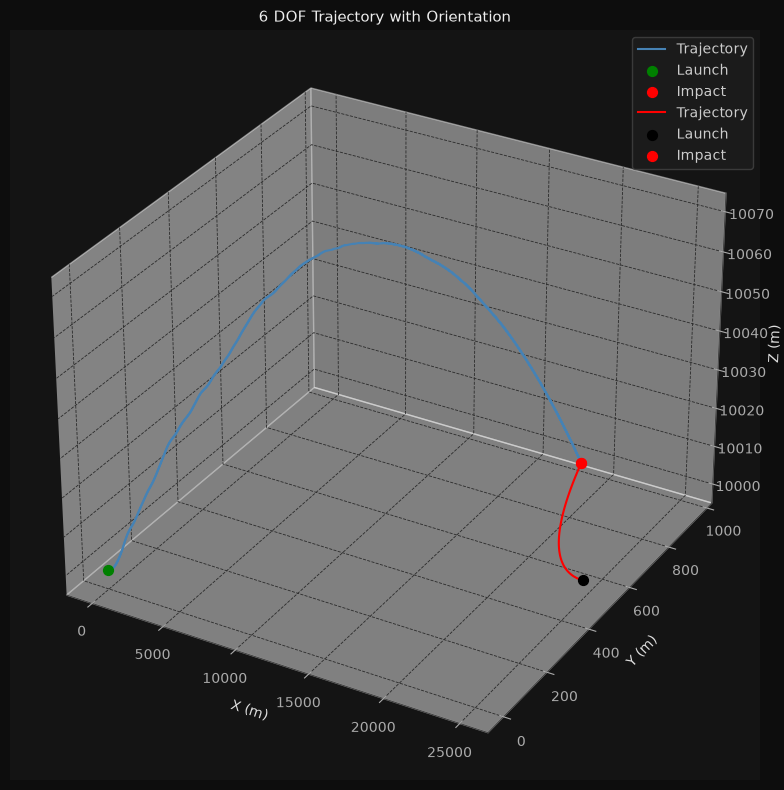

In [4]:
def quat_to_rotation_matrix(w, x, y, z):
    """Convert quaternion to 3x3 rotation matrix."""
    return np.array([
        [1-2*(y**2+z**2), 2*(x*y-z*w),     2*(x*z+y*w)    ],
        [2*(x*y+z*w),     1-2*(x**2+z**2), 2*(y*z-x*w)    ],
        [2*(x*z-y*w),     2*(y*z+x*w),     1-2*(x**2+y**2)]
    ])

fig = plt.figure(figsize=(12, 8))
ax  = fig.add_subplot(111, projection='3d')

# Plot trajectory
ax.plot(x, y, z, color='steelblue', linewidth=1.5, label='Trajectory')
ax.scatter(x[0],  y[0],  z[0],  color='green', s=50, zorder=5, label='Launch')
ax.scatter(x[-1], y[-1], z[-1], color='red',   s=50, zorder=5, label='Impact')


ax.plot(tx, ty, tz, color='red', linewidth=1.5, label='Trajectory')
ax.scatter(tx[0],  ty[0],  tz[0],  color='black', s=50, zorder=5, label='Launch')
ax.scatter(tx[-1], ty[-1], tz[-1], color='red',   s=50, zorder=5, label='Impact')


# # Draw orientation arrows at regular intervals
# arrow_interval = max(1, len(df) // 20)  # ~20 arrows total
# arrow_scale    = max(z.max(), x.max()) * 0.05  # scale relative to trajectory size
# nose_vector    = np.array([0.0, 0.0, 1.0])  # projectile nose points along z in body frame

# for i in range(0, len(df), arrow_interval):
#     R   = quat_to_rotation_matrix(qw[i], qx[i], qy[i], qz[i])
#     dir = R @ nose_vector * arrow_scale
#     ax.quiver(
#         x[i], y[i], z[i],
#         dir[0], dir[1], dir[2],
#         color='darkorange', linewidth=1.2, arrow_length_ratio=0.3
#     )

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('6 DOF Trajectory with Orientation')
ax.legend()
plt.tight_layout()
plt.show()

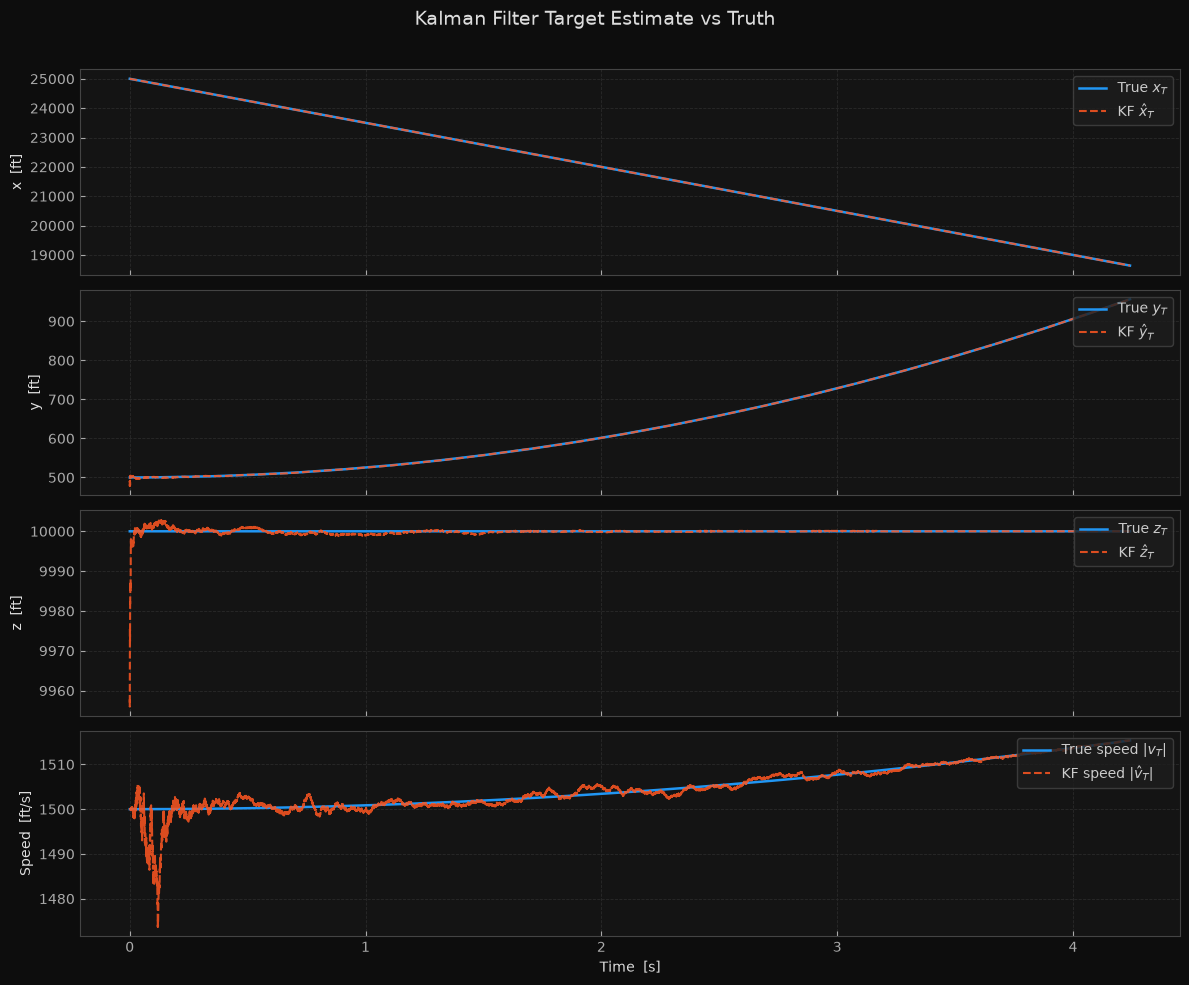

In [5]:
# ── Figure 1 — KF vs Truth: position + speed ──────────────────────────────────
fig1, axes1 = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
fig1.suptitle('Kalman Filter Target Estimate vs Truth', fontsize=14, y=0.98)
 
ax_x, ax_y, ax_z, ax_spd = axes1
 
# X
ax_x.plot(t, tx,  color=TRUTH_COLOR, lw=LW_TRUTH, label='True $x_T$')
ax_x.plot(t, ktx, color=KF_COLOR,    lw=LW_KF,    alpha=ALPHA_KF,
          linestyle='--', label='KF $\\hat{x}_T$')
ax_x.set_ylabel('x  [ft]')
ax_x.legend(loc='upper right')
ax_x.grid(True)
 
# Y
ax_y.plot(t, ty,  color=TRUTH_COLOR, lw=LW_TRUTH, label='True $y_T$')
ax_y.plot(t, kty, color=KF_COLOR,    lw=LW_KF,    alpha=ALPHA_KF,
          linestyle='--', label='KF $\\hat{y}_T$')
ax_y.set_ylabel('y  [ft]')
ax_y.legend(loc='upper right')
ax_y.grid(True)
 
# Z
ax_z.plot(t, tz,  color=TRUTH_COLOR, lw=LW_TRUTH, label='True $z_T$')
ax_z.plot(t, ktz, color=KF_COLOR,    lw=LW_KF,    alpha=ALPHA_KF,
          linestyle='--', label='KF $\\hat{z}_T$')
ax_z.set_ylabel('z  [ft]')
ax_z.legend(loc='upper right')
ax_z.grid(True)
 
# Speed
ax_spd.plot(t, true_speed, color=TRUTH_COLOR, lw=LW_TRUTH, label='True speed $|v_T|$')
ax_spd.plot(t, kf_speed,   color=KF_COLOR,    lw=LW_KF,    alpha=ALPHA_KF,
            linestyle='--', label='KF speed $|\\hat{v}_T|$')
ax_spd.set_ylabel('Speed  [ft/s]')
ax_spd.set_xlabel('Time  [s]')
ax_spd.legend(loc='upper right')
ax_spd.grid(True)
 
for ax in axes1:
    ax.tick_params(axis='both', which='both', direction='in')
 
fig1.tight_layout(rect=[0, 0, 1, 0.97])

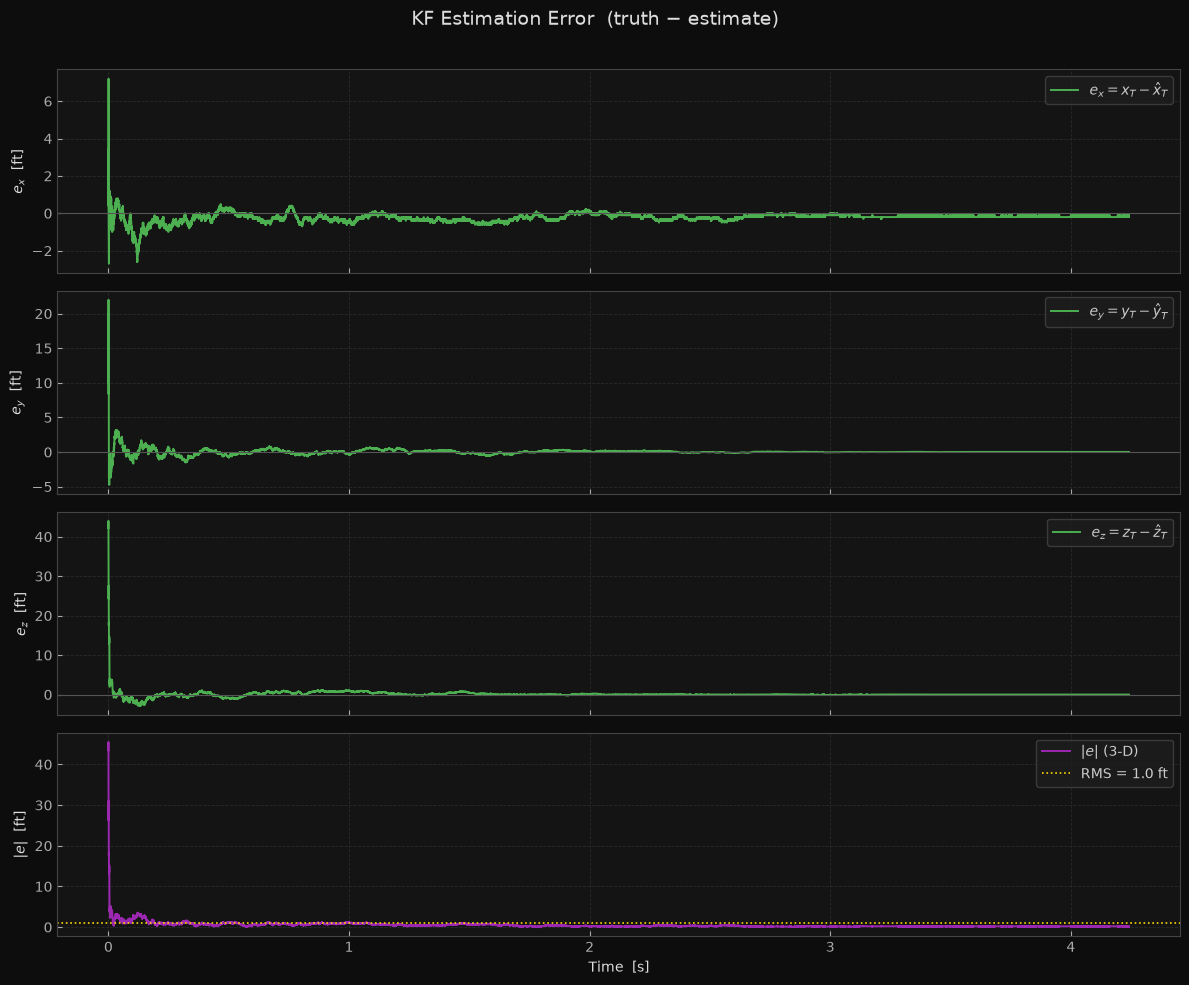

In [6]:
# ── Figure 2 — Estimation Error (residuals) ────────────────────────────────────
fig2, axes2 = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
fig2.suptitle('KF Estimation Error  (truth − estimate)', fontsize=14, y=0.98)
 
ax_ex, ax_ey, ax_ez, ax_e3 = axes2
ZERO_KW = dict(color='#555', lw=0.8, linestyle='-')
 
# e_x
ax_ex.plot(t, ex, color=ERR_COLOR, lw=LW_ERR, label='$e_x = x_T - \\hat{x}_T$')
ax_ex.axhline(0, **ZERO_KW)
ax_ex.set_ylabel('$e_x$  [ft]')
ax_ex.legend(loc='upper right')
ax_ex.grid(True)
 
# e_y
ax_ey.plot(t, ey, color=ERR_COLOR, lw=LW_ERR, label='$e_y = y_T - \\hat{y}_T$')
ax_ey.axhline(0, **ZERO_KW)
ax_ey.set_ylabel('$e_y$  [ft]')
ax_ey.legend(loc='upper right')
ax_ey.grid(True)
 
# e_z
ax_ez.plot(t, ez, color=ERR_COLOR, lw=LW_ERR, label='$e_z = z_T - \\hat{z}_T$')
ax_ez.axhline(0, **ZERO_KW)
ax_ez.set_ylabel('$e_z$  [ft]')
ax_ez.legend(loc='upper right')
ax_ez.grid(True)
 
# |e| with RMS annotation
ax_e3.plot(t, e3d, color=MAG_COLOR, lw=LW_ERR, label='$|e|$ (3-D)')
rms_val = np.sqrt(np.mean(e3d**2))
ax_e3.axhline(rms_val, color='#FFD700', lw=1.2, linestyle=':', label=f'RMS = {rms_val:.1f} ft')
ax_e3.set_ylabel('$|e|$  [ft]')
ax_e3.set_xlabel('Time  [s]')
ax_e3.legend(loc='upper right')
ax_e3.grid(True)
 
for ax in axes2:
    ax.tick_params(axis='both', which='both', direction='in')
 
fig2.tight_layout(rect=[0, 0, 1, 0.97])

## 1. Quaternion Components and Normalization

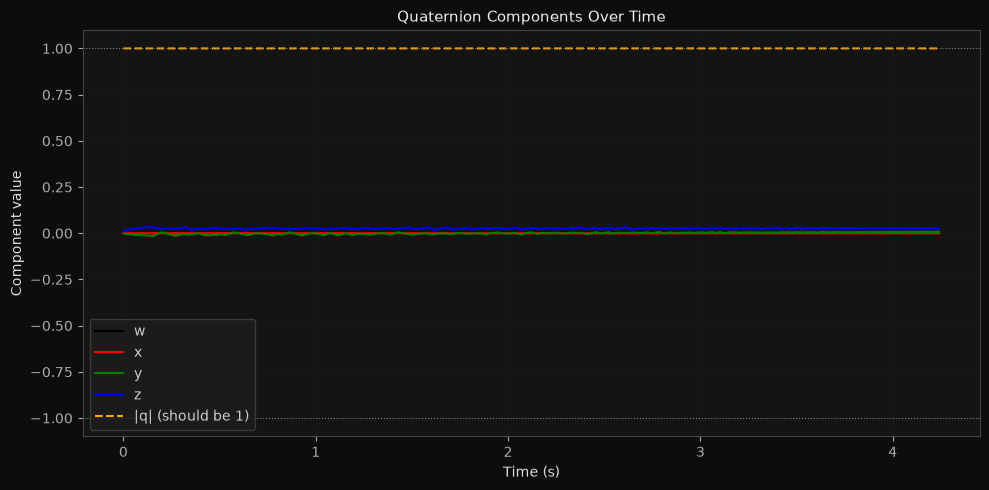

In [7]:
magnitude = np.sqrt(qw**2 + qx**2 + qy**2 + qz**2)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t, qw, label='w', color='black')
ax.plot(t, qx, label='x', color='red')
ax.plot(t, qy, label='y', color='green')
ax.plot(t, qz, label='z', color='blue')
ax.plot(t, magnitude, label='|q| (should be 1)', color='orange', linestyle='--')
ax.axhline(y=1.0,  color='gray', linestyle=':', linewidth=0.8)
ax.axhline(y=-1.0, color='gray', linestyle=':', linewidth=0.8)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Component value')
ax.set_title('Quaternion Components Over Time')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
## 3. Euler Angles Over Time

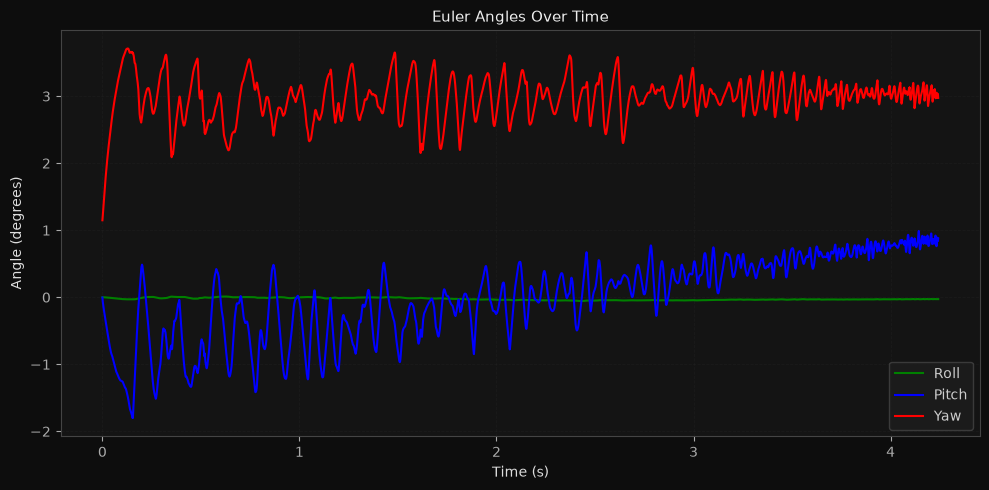

In [9]:
# Convert quaternion to Euler angles (roll, pitch, yaw)
roll  = np.arctan2(2*(qw*qx + qy*qz), 1 - 2*(qx**2 + qy**2))
pitch = np.arcsin(np.clip(2*(qw*qy - qz*qx), -1.0, 1.0))
yaw   = np.arctan2(2*(qw*qz + qx*qy), 1 - 2*(qy**2 + qz**2))

# Convert to degrees and unwrap to remove discontinuities
roll_deg  = np.degrees(np.unwrap(roll))
pitch_deg = np.degrees(np.unwrap(pitch))
yaw_deg   = np.degrees(np.unwrap(yaw))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t, roll_deg,  label='Roll',  color='green')
ax.plot(t, pitch_deg, label='Pitch', color='blue')
ax.plot(t, yaw_deg,   label='Yaw',   color='red')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Angle (degrees)')
ax.set_title('Euler Angles Over Time')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


── KF Innovations (pre-fit residuals) ──
  y_x  mean=-0.1 ft  std=21.1 ft
  y_y  mean=-0.1 ft  std=53.9 ft
  y_z  mean=+0.1 ft  std=37.9 ft
  |y|  RMS : 69.2 ft
  (zero-mean + white noise => filter is consistent)


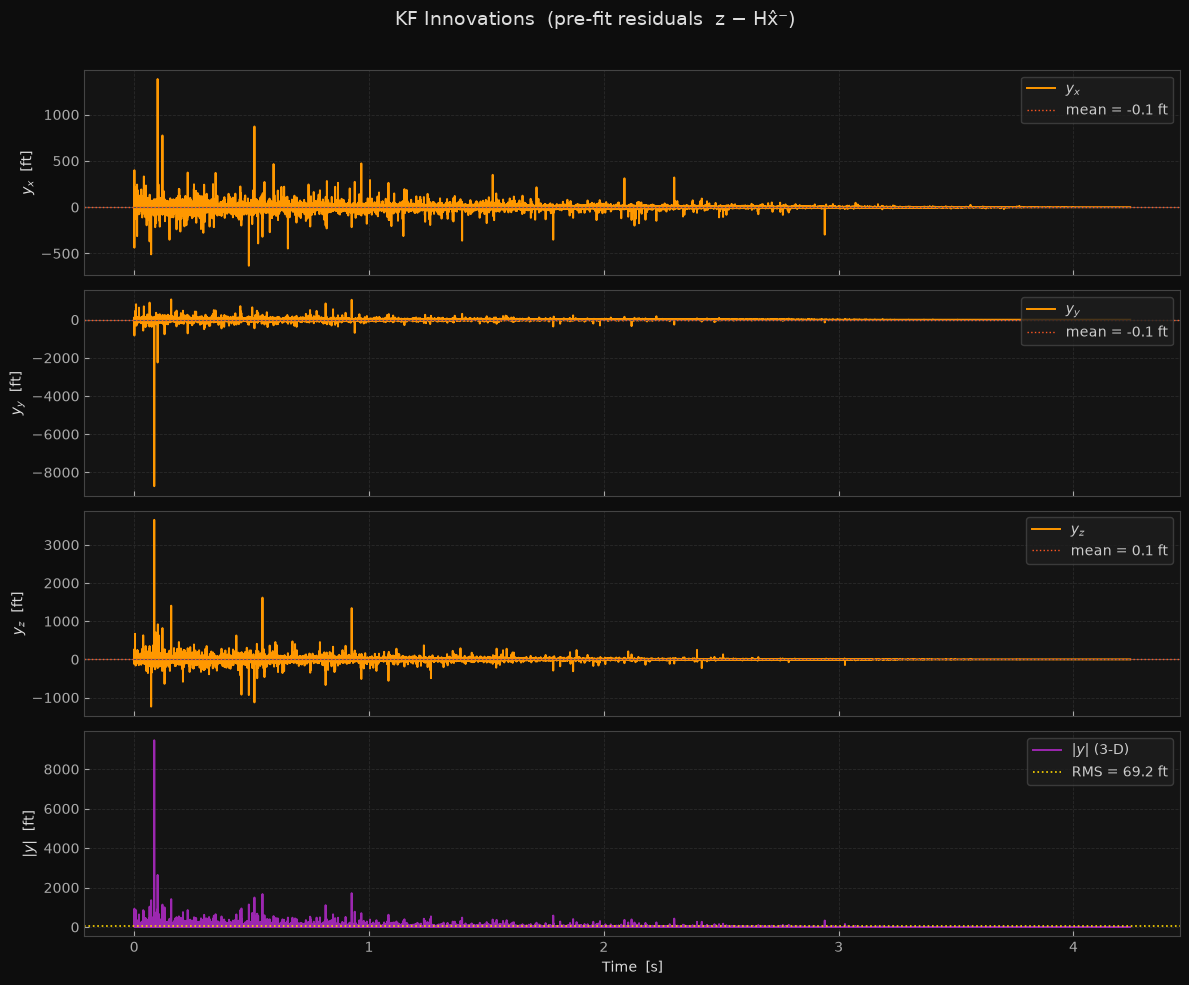

In [10]:
# ── Figure 4 — KF Innovations (pre-fit residuals) ─────────────────────────────
INNOV_COLOR = '#FF9800'   # amber
 
fig4, axes4 = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
fig4.suptitle('KF Innovations  (pre-fit residuals  z − Hx̂⁻)', fontsize=14, y=0.98)
 
ax_i1, ax_i2, ax_i3, ax_i4 = axes4
 
ax_i1.plot(t, innov_x, color=INNOV_COLOR, lw=LW_ERR, label='$y_x$')
ax_i1.axhline(0, **ZERO_KW)
ax_i1.axhline(innov_x.mean(), color='#FF5722', lw=1.0, linestyle=':', label=f'mean = {innov_x.mean():.1f} ft')
ax_i1.set_ylabel('$y_x$  [ft]')
ax_i1.legend(loc='upper right')
ax_i1.grid(True)
 
ax_i2.plot(t, innov_y, color=INNOV_COLOR, lw=LW_ERR, label='$y_y$')
ax_i2.axhline(0, **ZERO_KW)
ax_i2.axhline(innov_y.mean(), color='#FF5722', lw=1.0, linestyle=':', label=f'mean = {innov_y.mean():.1f} ft')
ax_i2.set_ylabel('$y_y$  [ft]')
ax_i2.legend(loc='upper right')
ax_i2.grid(True)
 
ax_i3.plot(t, innov_z, color=INNOV_COLOR, lw=LW_ERR, label='$y_z$')
ax_i3.axhline(0, **ZERO_KW)
ax_i3.axhline(innov_z.mean(), color='#FF5722', lw=1.0, linestyle=':', label=f'mean = {innov_z.mean():.1f} ft')
ax_i3.set_ylabel('$y_z$  [ft]')
ax_i3.legend(loc='upper right')
ax_i3.grid(True)
 
ax_i4.plot(t, innov_3d, color=MAG_COLOR, lw=LW_ERR, label='$|y|$ (3-D)')
innov_rms = np.sqrt(np.mean(innov_3d**2))
ax_i4.axhline(innov_rms, color='#FFD700', lw=1.2, linestyle=':', label=f'RMS = {innov_rms:.1f} ft')
ax_i4.set_ylabel('$|y|$  [ft]')
ax_i4.set_xlabel('Time  [s]')
ax_i4.legend(loc='upper right')
ax_i4.grid(True)
 
for ax in axes4:
    ax.tick_params(axis='both', which='both', direction='in')
 
fig4.tight_layout(rect=[0, 0, 1, 0.97])
 
# Innovation stats
print(f"\n── KF Innovations (pre-fit residuals) ──")
for label, arr in [('y_x', innov_x), ('y_y', innov_y), ('y_z', innov_z)]:
    print(f"  {label}  mean={arr.mean():+.1f} ft  std={arr.std():.1f} ft")
print(f"  |y|  RMS : {innov_rms:.1f} ft")
print(f"  (zero-mean + white noise => filter is consistent)")